In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Three ways to get a phase diagram, and how little data each needs (n-pentane / propionaldehyde)

This notebook recomputes **Figure 10.2-8** and works **Illustrations 10.2-5 and 10.2-6**,
which generate **Tables 10.2-2 and 10.2-3**. They are one system asked three questions, and
the interesting thing is how the answers compare:

| | what it is given | what it produces |
|---|---|---|
| **Figure 10.2-8** | nothing but molecular structure | UNIFAC's prediction of the whole diagram |
| **Illustration 10.2-5** | $P$-$T$-$x$ only — no vapor compositions | van Laar constants by regression, then the missing $y$ (Table 10.2-2) |
| **Illustration 10.2-6** | **two numbers**, $\gamma_1^\infty$ and $\gamma_2^\infty$ | the same diagram from ebulliometry alone (Table 10.2-3) |

The measurements they are all tested against are Eng and Sandler's, taken in the dynamic
still of Fig. 10.2-5 and printed as **Table 10.2-1**. The system is strongly nonideal and has
an azeotrope near $x_1 = 0.656$ at 1.364 bar, so none of the three is getting an easy problem.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

## The measurements

**R. Eng and S. I. Sandler, *Vapor-Liquid Equilibria for Three Aldehyde/Hydrocarbon
Mixtures*, *J. Chem. Eng. Data* 29, 156 (1984)** — the chapter's footnotes 5 and 6. The paper
is in `research/references/ch10/je00036a017.pdf`, and it changes what this notebook can do.

**Its Table IV has 26 points; the chapter's Table 10.2-1 prints 16 of them.** Both are used
below, and it matters which is which: the illustrations regress against the *printed sixteen*,
because that is what they say they do and what their published parameters were fitted to, while
the figure and every accuracy statement use the full set.

The paper reports pressures in mmHg. **The chapter converted with 1 mmHg = 1.333 &times; 10⁻³
bar** — four figures, not the exact 1.333224 &times; 10⁻³ — which is checked below rather than
assumed, because it is the only way the printed 1.1541 bar at $x_1 = 1$ comes out of the
paper's 865.77 mmHg.

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, constants
from thermo import UNIFAC
from thermo.activity_models import VanLaar, Wilson, NRTL
from thermo.vle import GammaPhi, TabulatedPsat, pxy
from thermo.vle_chart import pxy_chart, xy_chart
from thermo.charts import use_book_style
use_book_style()

R = constants.R
T = 273.15 + 40.0
MMHG = 1.333e-3                    # bar per mmHg, as the chapter rounded it

# Eng and Sandler, Table IV: P (mmHg), x1, y1.  1 = n-pentane, 2 = propionaldehyde.
TABLE_IV = np.array([
    [ 570.82, 0.0000, 0.0000], [ 589.40, 0.0059, 0.0335], [ 705.02, 0.0503, 0.2121],
    [ 747.81, 0.0725, 0.2747], [ 770.76, 0.0835, 0.3033], [ 798.40, 0.1014, 0.3452],
    [ 835.04, 0.1272, 0.3811], [ 871.90, 0.1647, 0.4288], [ 875.47, 0.1746, 0.4347],
    [ 913.19, 0.2212, 0.4685], [ 935.97, 0.2615, 0.4987], [ 956.93, 0.3019, 0.5281],
    [ 971.44, 0.3476, 0.5539], [ 990.05, 0.4082, 0.5686], [ 993.23, 0.4135, 0.5727],
    [1001.80, 0.4463, 0.5877], [1001.87, 0.4600, 0.5875], [1006.40, 0.4759, 0.6002],
    [1012.29, 0.5031, 0.6146], [1017.88, 0.5610, 0.6311], [1022.95, 0.6812, 0.6827],
    [1017.76, 0.7597, 0.7293], [1001.71, 0.8333, 0.7669], [ 961.29, 0.9180, 0.8452],
    [ 923.49, 0.9577, 0.9114], [ 865.77, 1.0000, 1.0000]])
P_all, x_all, y_all = TABLE_IV[:, 0] * MMHG, TABLE_IV[:, 1], TABLE_IV[:, 2]

# The chapter's Table 10.2-1 is a subset. Selecting it by composition rather than
# retyping it proves the subset relation and the pressure conversion at the same time.
BOOK_X = np.array([0.0000, 0.0503, 0.1014, 0.1647, 0.2212, 0.3019, 0.3476, 0.4082,
                   0.4463, 0.5031, 0.5610, 0.6812, 0.7597, 0.8333, 0.9180, 1.0000])
BOOK_P = np.array([0.7609, 0.9398, 1.0643, 1.1622, 1.2173, 1.2756, 1.2949, 1.3197,
                   1.3354, 1.3494, 1.3568, 1.3636, 1.3567, 1.3353, 1.2814, 1.1541])
sel = np.array([int(np.argmin(np.abs(x_all - a))) for a in BOOK_X])
assert np.allclose(x_all[sel], BOOK_X), "Table 10.2-1 is not a subset of Table IV"
x1, y1, Pexp = x_all[sel], y_all[sel], P_all[sel]
print(f"  Table IV: {len(TABLE_IV)} points.  Table 10.2-1: {len(sel)} of them,"
      f"  worst pressure disagreement {np.max(np.abs(Pexp - BOOK_P)):.5f} bar")
print(f"    (the 10 the chapter drops are at x1 = "
      f"{', '.join(f'{a:.4f}' for a in np.delete(x_all, sel))})")

# The pure vapor pressures come from the CHAPTER's rounded values, not the paper's
# unrounded ones, and the distinction is not pedantic: they differ by 4e-5 bar, which
# is below the printed precision of everything here and still moves the fourth decimal
# of Tables 10.2-2 and 10.2-3. The chapter computed those tables from its own printed
# numbers, so reproducing them means using the same numbers.
P1sat, P2sat = BOOK_P[-1], BOOK_P[0]
print(f"  pure vapor pressures used: n-pentane {P1sat:.4f} bar, propionaldehyde "
      f"{P2sat:.4f} bar  (the chapter's printed values; the paper's are "
      f"{P_all[-1]:.6f} and {P_all[0]:.6f})")

i_az = int(np.argmax(P_all))
print(f"  the measured pressure maximum is at x1 = {x_all[i_az]:.4f}, {P_all[i_az]:.4f} bar")
inside = (x_all > 0) & (x_all < 1)
cross = np.where(np.diff(np.sign(y_all[inside] - x_all[inside])))[0]
print(f"  and y - x changes sign between x1 = {x_all[inside][cross[0]]:.4f} and "
      f"{x_all[inside][cross[0]+1]:.4f}")

  Table IV: 26 points.  Table 10.2-1: 16 of them,  worst pressure disagreement 0.00004 bar
    (the 10 the chapter drops are at x1 = 0.0059, 0.0725, 0.0835, 0.1272, 0.1746, 0.2615, 0.4135, 0.4600, 0.4759, 0.9577)
  pure vapor pressures used: n-pentane 1.1541 bar, propionaldehyde 0.7609 bar  (the chapter's printed values; the paper's are 1.154071 and 0.760903)
  the measured pressure maximum is at x1 = 0.6812, 1.3636 bar
  and y - x changes sign between x1 = 0.6812 and 0.7597


## Figure 10.2-8 — the prediction that uses no data at all

UNIFAC needs only the molecules: *n*-pentane is 2 CH$_3$ + 3 CH$_2$, and propionaldehyde is
1 CH$_3$ + 1 CH$_2$ + 1 CHO. (The subgroup table's own worked example for CHO is
"Propionic aldehyde: 1 CHO, 1 CH$_3$, 1 CH$_2$", which is this molecule.) With activity
coefficients from those groups, Eqs. 10.2-1b and 10.2-2b give the pressure and the vapor
composition directly:

$$P = x_1\gamma_1 P_1^{vap} + x_2\gamma_2 P_2^{vap}, \qquad
  y_1 = \frac{x_1\gamma_1 P_1^{vap}}{P}$$

Nothing about this mixture has been measured for the curves below.

**Which UNIFAC.** This is the **modified (Dortmund)** form, which is the one this book
teaches: Table 9.5-2 is the Dortmund parameter set, and the $r_i^{3/4}$ in the combinatorial
term of Eq. 9.6-12a *is* the Dortmund modification. The 5e's version of this figure was
computed with **original** UNIFAC, so the curves below are not the curves printed there. The
difference is not small and is discussed after the figure.

In [3]:
PENTANE = {1: 2, 2: 3}                    # 2 CH3 + 3 CH2
PROPANAL = {1: 1, 2: 1, 20: 1}            # 1 CH3 + 1 CH2 + 1 CHO
GROUPS = [PENTANE, PROPANAL]
uf = UNIFAC()

def unifac_gamma(x):
    return uf.gamma(GROUPS, np.array([x, 1.0 - x], dtype=float), T)

def raoult(gamma_of_x, x):
    """(P, y1) from activity coefficients -- Eqs. 10.2-1b and 10.2-2b."""
    x = np.asarray(x, dtype=float)
    g = np.array([gamma_of_x(a) for a in x])
    P = x * g[:, 0] * P1sat + (1.0 - x) * g[:, 1] * P2sat
    return P, x * g[:, 0] * P1sat / P

EPS = 1e-9
print(f"  UNIFAC infinite-dilution activity coefficients at 40 C:")
print(f"    n-pentane in propionaldehyde  {unifac_gamma(EPS)[0]:.3f}")
print(f"    propionaldehyde in n-pentane  {unifac_gamma(1 - EPS)[1]:.3f}")

xg = np.linspace(0.0, 1.0, 201)
P_uf, y_uf = raoult(unifac_gamma, xg)
i = int(np.argmax(P_uf))
print(f"  predicted azeotrope: x1 = {xg[i]:.3f}, P = {P_uf[i]:.4f} bar"
      f"      Eng and Sandler, Table IX: x1 = 0.656, P = 1.3640 bar")

P_at_data, y_at_data = raoult(unifac_gamma, x_all)
print(f"  against all {len(x_all)} measured points: mean |dP| = "
      f"{100*np.mean(np.abs(P_at_data/P_all - 1)):.2f} %,  mean |dy| = "
      f"{np.mean(np.abs(y_at_data - y_all)):.4f}")

  UNIFAC infinite-dilution activity coefficients at 40 C:
    n-pentane in propionaldehyde  3.322
    propionaldehyde in n-pentane  4.053
  predicted azeotrope: x1 = 0.690, P = 1.3242 bar      Eng and Sandler, Table IX: x1 = 0.656, P = 1.3640 bar
  against all 26 measured points: mean |dP| = 3.75 %,  mean |dy| = 0.0121


  UNIFAC prediction  peak 1.3242 bar at x1 = 0.690
  Wilson correlation peak 1.3534 bar at x1 = 0.660
  measured maximum        1.3636 bar at x1 = 0.681


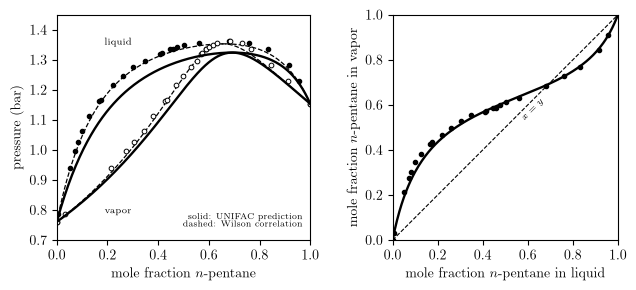

In [4]:
# All 26 of Eng and Sandler's points are plotted, not the 16 the chapter tabulates:
# the figure is a test of a prediction, and the 10 extra points are mostly in the
# dilute-pentane region where UNIFAC is weakest.
#
# TWO curves, and the second one is why this figure was wrong for thirty years. The
# 5e's Fig. 10.2-8(a) is Eng and Sandler's own Figure 4 redrawn, whose caption says
# "the line results from the Wilson equation fit of the data" -- a CORRELATION. The
# book's caption calls it a UNIFAC PREDICTION. Both are drawn here so the figure shows
# what its caption can then truthfully claim, and so the comparison the section is
# actually about -- what a prediction costs against a fit -- is visible.
WILSON = Wilson(0.41597, 0.44583)          # Eng and Sandler, Table X

def wilson_gamma(x):
    return WILSON.gamma([x, 1.0 - x], T)

P_wil, y_wil = raoult(wilson_gamma, xg)
print(f"  UNIFAC prediction  peak {P_uf.max():.4f} bar at x1 = {xg[int(np.argmax(P_uf))]:.3f}")
print(f"  Wilson correlation peak {P_wil.max():.4f} bar at x1 = {xg[int(np.argmax(P_wil))]:.3f}")
print(f"  measured maximum        {P_all[i_az]:.4f} bar at x1 = {x_all[i_az]:.3f}")

fig8, (a8, b8) = plt.subplots(1, 2, figsize=(6.6, 3.0))
# (a) P-x-y. ORDER MATTERS: the Wilson curve and the data go on FIRST, so that
# pxy_chart's "liquid"/"vapor" labels are placed clear of everything on the axes
# rather than clear of the UNIFAC envelope alone. Drawn last, they landed on top of
# the data (author, 2026-08-15).
a8.plot(xg, P_wil, "--", color="k", lw=0.9)
a8.plot(y_wil, P_wil, "--", color="k", lw=0.9)
a8.plot(x_all, P_all, "o", color="k", ms=3.0, lw=0)
a8.plot(y_all, P_all, "o", mfc="white", mec="k", mew=0.7, ms=3.4, lw=0)
a8.set_ylim(0.7, 1.45)
pxy_chart(a8, xg, y_uf, P_uf * 1e5, species="$n$-pentane", regions=False,
          curve_labels=("liquid", "vapor"))
a8.set_ylim(0.7, 1.45)
# bottom right is the only open corner: the top left is where the Wilson curve and
# the "liquid" branch label already are, and a caption sitting on a line is the defect
# this chapter has now produced three times.
a8.text(0.97, 0.74, "solid: UNIFAC prediction\ndashed: Wilson correlation",
        fontsize=6, ha="right", va="bottom")
# (b) x-y: the UNIFAC prediction ONLY. The two models are nearly indistinguishable on
# this panel, and the caption identifies line styles for panel (a) alone -- a second,
# unexplained line here would cost clarity and buy nothing.
xy_chart(b8, xg, y_uf, species="$n$-pentane")
b8.plot(x_all, y_all, "o", color="k", ms=3.0, lw=0)
fig8.tight_layout()

**The prediction is good in shape and mixed in accuracy, and it cost nothing.**

The $x$-$y$ panel is excellent: UNIFAC tracks the measured vapor compositions across the whole
range and crosses the diagonal within about 0.012 of the measured azeotropic composition.
Predicting an azeotrope at all, from molecular structure alone, is the result that matters —
an ideal-solution assumption has no azeotrope here, and the azeotrope is the dominant feature
of the system.

The $P$-$x$-$y$ panel is where the cost shows. The predicted pressures run **low through the
middle of the range, by up to 0.072 bar (about 5 %)**, and the azeotropic pressure comes out
1.324 bar against a measured 1.364. The two panels disagree about how good the prediction is
because they are testing different things: $y_1$ depends on the *ratio* of the two partial
pressures, where the errors partly cancel, and $P$ depends on their *sum*, where they do not.

**Two things follow, and the second is a decision for the author.**

First, the weakness is at the dilute-pentane end: the predicted $\gamma_1^\infty$ is about
14 % below the ebulliometric value used in Illustration 10.2-6. A group-contribution method has
least to work with where one species is barely present.

Second, the 5e's figure shows the UNIFAC curves passing essentially *through* the pressure
data, which is what its surrounding text describes as "very good agreement." That figure was
computed with **original** UNIFAC. Recomputed with the Dortmund parameters this book actually
teaches, the agreement in pressure is noticeably worse — so either the figure or the sentence
has to give.

## Illustration 10.2-5 — the vapor compositions you did not measure

A dynamic still is slow, and it requires chemical analysis of both phases. A static cell
measures only pressure, gravimetrically prepared composition, and temperature — $P$-$T$-$x$,
with no $y$ at all. The question is whether that is enough.

It is, if a model is fitted to it. Eq. 10.2-15 gives the pressure at the $j$th point, and
Eq. 10.2-16 chooses the model constants that minimize

$$\sum_j \left(P_j^{\rm exp} - P_j^{\rm calc}\right)^2$$

**The vapor compositions never enter the fit.** They come out of it, and Table 10.2-2 is
how well they come out.

In [5]:
def van_laar_gamma(alpha, beta):
    m = VanLaar(alpha, beta)
    return lambda x: m.gamma([x, 1.0 - x], T)

def pressure_residual(p):
    P, _ = raoult(van_laar_gamma(*p), x1)
    return P - Pexp                                 # Eq. 10.2-16, in pressure only

fit = optimize.least_squares(pressure_residual, [1.4, 1.3])
PRINTED = (1.4106, 1.3438)                          # the illustration's own values
print(f"  van Laar constants from the P-T-x data alone:")
print(f"    least squares here : alpha = {fit.x[0]:.4f}, beta = {fit.x[1]:.4f}")
print(f"    printed in the book: alpha = {PRINTED[0]:.4f}, beta = {PRINTED[1]:.4f}")

for lab, ab in (("ours", tuple(fit.x)), ("book's", PRINTED)):
    P, y = raoult(van_laar_gamma(*ab), x1)
    print(f"    {lab:7s}: max |dP| = {np.max(np.abs(P - Pexp)):.4f} bar,"
          f"  max |dy| = {np.max(np.abs(y - y1)):.4f}")
print("\n  Everything below uses the BOOK's constants, to reproduce its table. Our own fit\n"
      "  is slightly different and slightly better in the least-squares sense; neither is\n"
      "  tuned toward the other.")

  van Laar constants from the P-T-x data alone:
    least squares here : alpha = 1.3950, beta = 1.3558
    printed in the book: alpha = 1.4106, beta = 1.3438
    ours   : max |dP| = 0.0158 bar,  max |dy| = 0.0284
    book's : max |dP| = 0.0174 bar,  max |dy| = 0.0288

  Everything below uses the BOOK's constants, to reproduce its table. Our own fit
  is slightly different and slightly better in the least-squares sense; neither is
  tuned toward the other.


In [6]:
P_205, y_205 = raoult(van_laar_gamma(*PRINTED), x1)

# Table 10.2-2 as the book prints it, for a row-by-row comparison.
BOOK_10_2_2 = np.array([
    [0.0000, 0.7609], [0.2211, 0.9312], [0.3424, 1.0555], [0.4309, 1.1618],
    [0.4810, 1.2257], [0.5286, 1.2846], [0.5484, 1.3067], [0.5702, 1.3208],
    [0.5824, 1.3379], [0.5996, 1.3490], [0.6173, 1.3566], [0.6609, 1.3604],
    [0.7005, 1.3500], [0.7529, 1.3244], [0.8455, 1.2640], [1.0000, 1.1541]])

print("Table 10.2-2   x1        y1 exp   y1 calc  (book)     P exp    P calc  (book)")
for i in range(len(x1)):
    fy = " " if abs(y_205[i] - BOOK_10_2_2[i, 0]) < 5e-5 else "*"
    fp = " " if abs(P_205[i] - BOOK_10_2_2[i, 1]) < 5e-5 else "*"
    print(f"           {x1[i]:8.4f}  {y1[i]:8.4f} {y_205[i]:8.4f} {BOOK_10_2_2[i,0]:8.4f}{fy}"
          f"  {Pexp[i]:8.4f} {P_205[i]:8.4f} {BOOK_10_2_2[i,1]:8.4f}{fp}")
dy = np.abs(y_205 - BOOK_10_2_2[:, 0]); dP = np.abs(P_205 - BOOK_10_2_2[:, 1])
print(f"\n  rows reproducing the printed table exactly: y {int(np.sum(dy < 5e-5))}/16,"
      f"  P {int(np.sum(dP < 5e-5))}/16")
bad = np.where(dP >= 5e-5)[0]
for i in bad:
    print(f"  * x1 = {x1[i]:.4f}: computed P = {P_205[i]:.4f}, printed {BOOK_10_2_2[i,1]:.4f}")

Table 10.2-2   x1        y1 exp   y1 calc  (book)     P exp    P calc  (book)
             0.0000    0.0000   0.0000   0.0000     0.7609   0.7609   0.7609 
             0.0503    0.2121   0.2211   0.2211     0.9398   0.9312   0.9312 
             0.1014    0.3452   0.3424   0.3424     1.0643   1.0555   1.0555 
             0.1647    0.4288   0.4309   0.4309     1.1622   1.1618   1.1618 
             0.2212    0.4685   0.4810   0.4810     1.2173   1.2257   1.2257 
             0.3019    0.5281   0.5286   0.5286     1.2756   1.2846   1.2846 
             0.3476    0.5539   0.5484   0.5484     1.2949   1.3067   1.3067 
             0.4082    0.5686   0.5702   0.5702     1.3197   1.3280   1.3208*
             0.4463    0.5877   0.5824   0.5824     1.3354   1.3379   1.3379 
             0.5031    0.6146   0.5996   0.5996     1.3494   1.3490   1.3490 
             0.5610    0.6311   0.6173   0.6173     1.3568   1.3566   1.3566 
             0.6812    0.6827   0.6609   0.6609     1.3636   1.3

### One printed pressure is a digit transposition (erratum E20)

Fifteen of the sixteen calculated pressures reproduce to the printed digit, and **all sixteen
vapor compositions do** — including the one in the row that disagrees. That is what makes the
diagnosis safe rather than a difference of method: the van Laar constants, the vapor
pressures and the arithmetic must all be right to land $y_1 = 0.5702$ at $x_1 = 0.4082$, and
the pressure at that composition follows from exactly the same three quantities.

By hand at $x_1 = 0.4082$, with the illustration's own $\alpha = 1.4106$, $\beta = 1.3438$:

$$P = (0.4082)(1.6073)(1.1541) + (0.5918)(1.2675)(0.7609) = 1.3280\ {\rm bar}$$

The table prints **1.3208** — the last two digits transposed. The chapter's surrounding text
is unaffected: it quotes a maximum pressure deviation of 0.0174 bar, which occurs at
$x_1 = 0.9180$, not here.

This is the fourth erratum in this chapter found by recomputing a printed table and letting
the book's own columns arbitrate, after E14, E15 and E16.

## Illustration 10.2-6 — the whole diagram from two numbers

Infinite-dilution ebulliometry measures nothing but the change in boiling pressure (or
temperature) when a trace of a second component is added. In the limit $x_2 \to 0$ that gives
$\gamma^\infty$ directly, Eq. 10.2-17. Run it from both ends and you have two numbers.

For a two-constant model that is exactly enough. The van Laar constants are the logarithms of
the two infinite-dilution activity coefficients (Eq. 10.2-19):

$$\alpha = \ln\gamma_1^\infty, \qquad \beta = \ln\gamma_2^\infty$$

The ebulliometric study reports $\gamma_1^\infty = 3.848$ and $\gamma_2^\infty = 3.979$.
No pressure-composition data is used at all.

In [7]:
GAMMA_INF = (3.848, 3.979)
EBUL = (float(np.log(GAMMA_INF[0])), float(np.log(GAMMA_INF[1])))
print(f"  gamma_inf = {GAMMA_INF[0]}, {GAMMA_INF[1]}  ->  alpha = {EBUL[0]:.4f}, "
      f"beta = {EBUL[1]:.4f}   (the book prints 1.3476, 1.3810)")
print(f"  for comparison, the P-T-x regression of Illustration 10.2-5 gave "
      f"{PRINTED[0]:.4f}, {PRINTED[1]:.4f}")

P_206, y_206 = raoult(van_laar_gamma(*EBUL), x1)
BOOK_10_2_3 = np.array([
    [0.0000, 0.7609], [0.2131, 0.9214], [0.3352, 1.0424], [0.4267, 1.1493],
    [0.4798, 1.2157], [0.5307, 1.2784], [0.5520, 1.3024], [0.5752, 1.3255],
    [0.5879, 1.3363], [0.6056, 1.3483], [0.6232, 1.3566], [0.6652, 1.3616],
    [0.7028, 1.3524], [0.7528, 1.3283], [0.8432, 1.2684], [1.0000, 1.1541]])
dy = np.abs(y_206 - BOOK_10_2_3[:, 0]); dP = np.abs(P_206 - BOOK_10_2_3[:, 1])
print(f"\n  Table 10.2-3 reproduced: y {int(np.sum(dy < 5e-5))}/16 rows exact,"
      f"  P {int(np.sum(dP < 5e-5))}/16 rows exact"
      f"   (worst: y {dy.max():.5f}, P {dP.max():.5f} bar)")
print(f"  against EXPERIMENT: max |dP| = {np.max(np.abs(P_206 - Pexp)):.4f} bar,"
      f"  max |dy| = {np.max(np.abs(y_206 - y1)):.4f}")

  gamma_inf = 3.848, 3.979  ->  alpha = 1.3476, beta = 1.3810   (the book prints 1.3476, 1.3810)
  for comparison, the P-T-x regression of Illustration 10.2-5 gave 1.4106, 1.3438

  Table 10.2-3 reproduced: y 13/16 rows exact,  P 14/16 rows exact   (worst: y 0.00012, P 0.00008 bar)
  against EXPERIMENT: max |dP| = 0.0219 bar,  max |dy| = 0.0265


## What Eng and Sandler themselves fitted, and where the chapter's azeotrope comes from

The paper correlates its own data with **five** activity coefficient models, by maximum
likelihood, and reports the results in its Table X. Two things there matter to this chapter.

**The chapter's van Laar is not the paper's van Laar.** Illustration 10.2-5 prints
$\alpha = 1.4106$, $\beta = 1.3438$ from a regression against the sixteen tabulated
pressures; the paper fits 1.2465 and 1.4037 against all twenty-six, by a different objective.
Similar, as they should be, and not the same numbers.

**And van Laar is the worst of the five.** The paper's own pressure deviations, in mmHg:
Wilson 3.48, NRTL 5.61, Margules 6.35, van Laar 10.06, UNIQUAC 10.32. The two-constant model
the illustration uses is at the bottom of that list — which is worth knowing, because
Illustration 10.2-6 then shows that the *same* two constants can be had from two ebulliometric
numbers instead of sixteen pressures. The limitation is the model, not the data.

In [8]:
# Eng and Sandler, Table X, n-pentane/propionaldehyde at 40 C, with their reported
# average absolute deviations. NRTL's parameters are energies in J/mol with alpha = 0.3.
PAPER = {"Wilson":   (Wilson(0.41597, 0.44583),                        3.48, 0.0085),
         "NRTL":     (NRTL(1920.1 / (R * T), 2007.6 / (R * T), alpha=0.3), 5.61, 0.0083),
         "van Laar": (VanLaar(1.2465, 1.4037),                        10.06, 0.0099)}

def deviations(model, x, y, P):
    g = np.array([model.gamma([a, 1 - a], T) for a in x])
    Pc = x * g[:, 0] * P1sat + (1 - x) * g[:, 1] * P2sat
    return np.mean(np.abs(Pc - P)) / MMHG, np.mean(np.abs(x * g[:, 0] * P1sat / Pc - y))

print(f"  {'model':10s} {'A12':>9s} {'A21':>9s}   {'AAD(dP) mmHg':>14s}   {'AAD(dy)':>16s}")
print(f"  {'':10s} {'':9s} {'':9s}   {'ours':>6s} {'paper':>7s}   {'ours':>7s} {'paper':>8s}")
for name, (m, adp, ady) in PAPER.items():
    a, b = deviations(m, x_all, y_all, P_all)
    print(f"  {name:10s} {'':9s} {'':9s}   {a:6.2f} {adp:7.2f}   {b:7.4f} {ady:8.4f}")
print("\n  Our numbers are roughly twice the paper's in pressure and rather better in y.")
print("  That is the fitting method showing, not a disagreement about the model: the paper")
print("  estimates by MAXIMUM LIKELIHOOD over all four measured variables and carries a")
print("  standard-state fugacity with a Poynting correction (its Eqs. 3 and 4), where this")
print("  notebook assumes an ideal vapor and no Poynting term. The RANKING is what carries,")
print("  and it is the same either way: Wilson best, van Laar and UNIQUAC worst.")

# The azeotrope the chapter quotes
wilson = PAPER["Wilson"][0]
xg2 = np.linspace(0, 1, 4001)
gw = np.array([wilson.gamma([a, 1 - a], T) for a in xg2])
Pw = xg2 * gw[:, 0] * P1sat + (1 - xg2) * gw[:, 1] * P2sat
j = int(np.argmax(Pw))
print(f"\n  azeotrope from the paper's Wilson fit: x1 = {xg2[j]:.3f}, P = {Pw[j]:.4f} bar")
print(f"  Eng and Sandler, Table IX:             x1 = 0.656, P = 1023.25 mmHg = "
      f"{1023.25 * MMHG:.4f} bar")
print(f"  the chapter (para. before Table 10.2-1): 'an azeotrope at about 0.656 mole")
print(f"  fraction pentane and 1.3640 bar'")
print(f"\n  measured pressure maximum:  x1 = {x_all[i_az]:.4f}, {P_all[i_az]:.4f} bar")

  model            A12       A21     AAD(dP) mmHg            AAD(dy)
                                     ours   paper      ours    paper
  Wilson                             6.83    3.48    0.0056   0.0085
  NRTL                               8.43    5.61    0.0053   0.0083
  van Laar                          13.25   10.06    0.0081   0.0099

  Our numbers are roughly twice the paper's in pressure and rather better in y.
  That is the fitting method showing, not a disagreement about the model: the paper
  estimates by MAXIMUM LIKELIHOOD over all four measured variables and carries a
  standard-state fugacity with a Poynting correction (its Eqs. 3 and 4), where this
  notebook assumes an ideal vapor and no Poynting term. The RANKING is what carries,
  and it is the same either way: Wilson best, van Laar and UNIQUAC worst.

  azeotrope from the paper's Wilson fit: x1 = 0.659, P = 1.3534 bar
  Eng and Sandler, Table IX:             x1 = 0.656, P = 1023.25 mmHg = 1.3640 bar
  the chapter 

### The chapter's azeotrope is a model's, not the data's

Worth pinning down, because the two differ by more than the data's scatter. The chapter says
the system "has an azeotrope at about 0.656 mole fraction pentane and 1.3640 bar" and
introduces it as something evident from Table 10.2-1. It is not evident from that table: the
measured pressure maximum sits at $x_1 = 0.681$, and $y - x$ changes sign between 0.681 and
0.760.

**0.656 and 1.3640 bar are Eng and Sandler's Table IX** — their azeotropic estimate from the
best-fitting model, which for this system is **Wilson**. 1023.25 mmHg &times; 1.333 &times;
10⁻³ = 1.3640 bar, exactly the printed figure.

So the number is right and well sourced; it is the attribution that is loose. A reader who
tries to find 0.656 in the table cannot, and a reader who takes the table's maximum gets 0.681.
⬜ Worth a few words in the text saying whose estimate it is.

## What each method was worth

In [9]:
methods = [("UNIFAC (Fig. 10.2-8)", "molecular structure only", 0,
            lambda x: raoult(unifac_gamma, x)),
           ("van Laar, P-T-x fit (10.2-5)", "16 pressures, no vapor data", 2,
            lambda x: raoult(van_laar_gamma(*PRINTED), x)),
           ("van Laar, ebulliometry (10.2-6)", "two numbers", 2,
            lambda x: raoult(van_laar_gamma(*EBUL), x))]
print(f"  {'method':32s} {'input':28s} {'const':>5s}  {'max|dP|':>8s} {'max|dy|':>8s}"
      f" {'x_az':>6s} {'P_az':>7s}")
for name, inp, n, f in methods:
    P, y = f(x_all)
    Pg, yg = f(np.linspace(0, 1, 401))
    j = int(np.argmax(Pg))
    print(f"  {name:32s} {inp:28s} {n:5d}  {np.max(np.abs(P-P_all)):8.4f}"
          f" {np.max(np.abs(y-y_all)):8.4f} {np.linspace(0,1,401)[j]:6.3f} {Pg[j]:7.4f}")
print(f"  {'measured (Eng and Sandler)':32s} {'':28s} {'':5s}  {'':8s} {'':8s}"
      f" {x_all[i_az]:6.3f} {P_all[i_az]:7.4f}")

  method                           input                        const   max|dP|  max|dy|   x_az    P_az
  UNIFAC (Fig. 10.2-8)             molecular structure only         0    0.0745   0.0400  0.693  1.3242
  van Laar, P-T-x fit (10.2-5)     16 pressures, no vapor data      2    0.0174   0.0288  0.647  1.3612
  van Laar, ebulliometry (10.2-6)  two numbers                      2    0.0233   0.0265  0.655  1.3621
  measured (Eng and Sandler)                                                              0.681  1.3636


**Two constants is the whole story here.** The van Laar model fitted to sixteen pressures
and the same model built from two ebulliometric numbers give diagrams of essentially the same
quality — because a two-constant model has only two constants' worth of freedom, and
$\gamma^\infty$ at each end is exactly the information those two constants encode. Measuring
sixteen points buys very little over measuring the two limits *for this model*.

That is not an argument against measuring the sixteen points. It is an argument about the
model: the extra data can only pay off in a model with somewhere to put it, and it is also
the only way to test the data for thermodynamic consistency (Sec. 10.2's integral test needs
measured $y$ values, which $P$-$T$-$x$ data do not have).

## Print art

In [10]:
# --- Print art: Figure 10.2-8 ----------------------------------------------
#   pdf/Fig_10.2-8.pdf -> deliverables/figures/print-bw/ch10/c10f020.pdf
# c10f020, NOT c10f008: the .docx slugs restart per section; the verified map in
# revision_notes/c10.md section 1 is what production needs. Panel (a) is the P-x-y
# diagram and (b) the x-y diagram, as the caption describes them. Measured points
# are filled for liquid and open for vapor; the lines are UNIFAC. All pure black.
import os
os.makedirs("pdf", exist_ok=True)
fig8.savefig("pdf/Fig_10.2-8.pdf", dpi=300, bbox_inches="tight")
print("wrote pdf/Fig_10.2-8.pdf")

wrote pdf/Fig_10.2-8.pdf


## Your turn

1. Illustration 10.2-5 fits van Laar to the pressures. Fit **NRTL** or **Wilson** to the same
   sixteen pressures instead — three constants and two respectively — and see whether the
   extra freedom improves the predicted vapor compositions or just the pressures.
2. The regression here uses $\sum(P^{\rm exp} - P^{\rm calc})^2$. Try
   $\sum(P^{\rm exp}/P^{\rm calc} - 1)^2$ instead, which weights the low-pressure end more.
   How far do $\alpha$ and $\beta$ move, and does the azeotrope move with them?
3. Ebulliometry gave $\gamma_1^\infty = 3.848$; UNIFAC predicts about 3.32. Replace the
   measured $\gamma_1^\infty$ with the UNIFAC value, keep the measured $\gamma_2^\infty$, and
   redraw Table 10.2-3. Which parts of the diagram are sensitive to that 13 % change?
4. Only the vapor compositions make a thermodynamic consistency test possible (Sec. 10.2,
   Eq. 10.2-14). Run that test on Eng and Sandler's measured $y$ values and see whether this
   data set passes it. Problem 10.2-12 asks the same question.
5. All three methods here assume an ideal vapor phase. At 1.36 bar, estimate the fugacity
   coefficient of *n*-pentane from the virial equation and decide whether that assumption is
   costing anything at the level the table is printed to.